In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

file_path = 'players_data-2025_2026.csv' 
df = pd.read_csv(file_path, encoding='ISO-8859-1')

print(f"Dataset Loaded: {df.shape[0]} players, {df.shape[1]} features")
df.head()

Dataset Loaded: 2683 players, 102 features


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,27,21,...,1,0,0,14,37,5,30,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,16,3,...,0,0,0,4,3,1,25,2,1,0
3,4,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,1999.0,4,0,...,1,0,0,3,0,0,1,0,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0


In [2]:
#List the columns
print(df.columns.tolist())

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_s

In [3]:
#remove all columns where all values are empty or NaN
df.dropna(axis=1, how='all', inplace=True)
#remove all columns where all values are empty string
df = df.loc[:, (df != "").any(axis=0)]

#we want to predict the goals so lets test the correlation between the features

corr = df.corr(numeric_only=True)

# correlation with target
print(corr['Gls'].sort_values(ascending=False))

#removing these two cols because it already involves target so they will invalidate the statistics
remove_cols = ['G/Sh', 'G/SoT']
df = df.drop(columns=[c for c in remove_cols if c in df.columns])

#Now correlation with target (linear relationship test)
corr = df.corr(numeric_only=True)['Gls'].sort_values(ascending=False)
print(corr)




Gls                   1.000000
Gls_stats_shooting    1.000000
G-PK                  0.970190
G+A                   0.915404
SoT                   0.894505
                        ...   
CS%                        NaN
PKatt_stats_keeper         NaN
PKA                        NaN
PKsv                       NaN
PKm                        NaN
Name: Gls, Length: 81, dtype: float64
Gls                   1.000000
Gls_stats_shooting    1.000000
G-PK                  0.970190
G+A                   0.915404
SoT                   0.894505
                        ...   
CS%                        NaN
PKatt_stats_keeper         NaN
PKA                        NaN
PKsv                       NaN
PKm                        NaN
Name: Gls, Length: 79, dtype: float64


In [4]:
#based on above correlation result which shows nearly perfect correlation so lets remove those variables
remove_cols = [
    'Gls_stats_shooting',
    'G-PK',
    'G+A',
    'G/Sh',
    'G/SoT'
]

df = df.drop(columns=[c for c in remove_cols if c in df.columns])
corr = df.corr(numeric_only=True)['Gls'].sort_values(ascending=False)
print(corr)

Gls                     1.000000
SoT                     0.894505
Sh                      0.827823
PKatt                   0.621816
PKatt_stats_shooting    0.621816
                          ...   
CS%                          NaN
PKatt_stats_keeper           NaN
PKA                          NaN
PKsv                         NaN
PKm                          NaN
Name: Gls, Length: 76, dtype: float64


In [5]:
df = df.loc[:, ~df.columns.duplicated()]

drop_extra = [
    'CS%', 'PKA', 'PKsv', 'PKm'
]

df = df.drop(columns=[c for c in drop_extra if c in df.columns])

corr = df.corr(numeric_only=True)['Gls'].sort_values(ascending=False)
print(corr)

Gls                     1.000000
SoT                     0.894505
Sh                      0.827823
PKatt                   0.621816
PKatt_stats_shooting    0.621816
                          ...   
W                            NaN
D                            NaN
L                            NaN
CS                           NaN
PKatt_stats_keeper           NaN
Name: Gls, Length: 72, dtype: float64


In [6]:
df = df.drop(columns=['PKatt_stats_shooting'], errors='ignore')
features = [
    'SoT',
    'Sh',
    'PKatt'
]

#checking multicollinearity between independent variable which can exist as SoT and Sh is related.

X = df[features].dropna()

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif.sort_values("VIF", ascending=False))


  feature        VIF
0     SoT  14.162570
1      Sh  13.041745
2   PKatt   1.487610


In [7]:
#Based on the observation we saw SoT and sh has high variance so we will omit sh
features = ['SoT', 'PKatt']

X = df[features].fillna(0)
y = df['Gls']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8217221215613805


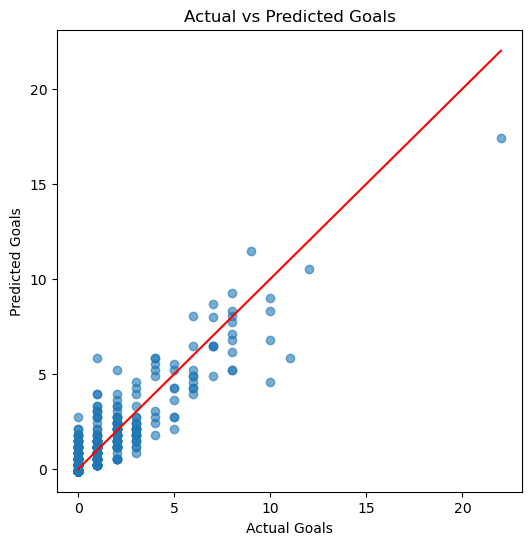

In [9]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Goals")
plt.ylabel("Predicted Goals")
plt.title("Actual vs Predicted Goals")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

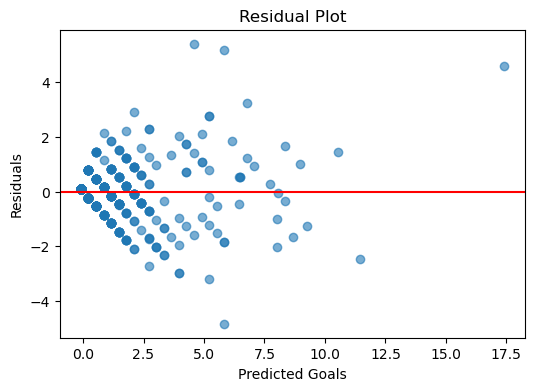

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel("Predicted Goals")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [12]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coef_df)

  Feature  Coefficient
0     SoT     0.311648
1   PKatt     0.628802
